La banque MNIST propose des images en ton de gris de 28 x 28 pixels, correspond à des matrices de 28 x 28 d'entiers compris entre 0 et 255



In [ ]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


L'ensemble des images du jeu de données MNIST contient 60000 images d'apprentissages et 10000 images de test, soit en tout 70000 iages de 28 x 28 pixels.

In [ ]:
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
train_labels.shape

(60000,)

In [ ]:
print(train_labels[:10])

[5 0 4 1 9 2 1 3 1 4]


In [ ]:
def plot_image(r,L,C):
  plt.figure(figsize=(10,10))
  for i in range(L*C):
    plt.subplot(L,C,i+1)
    plt.imshow(train_images[r+1],cmap='binary', interpolation='none')
    plt.xticks([])
    plt.yticks([])

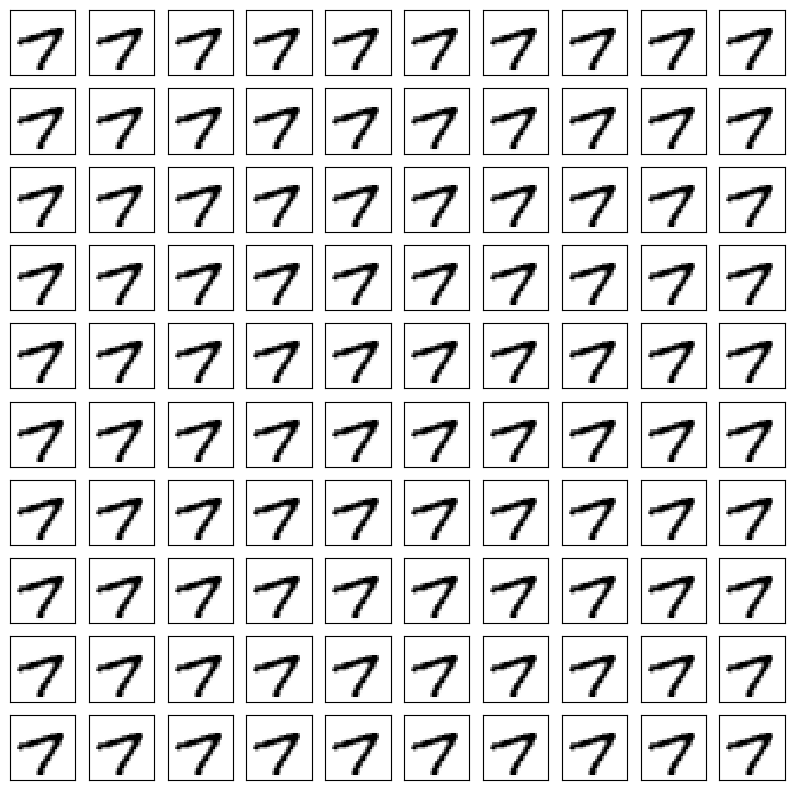

In [ ]:
plot_image(100,10,10)

# Pré-traitement des données

In [ ]:
nb_images_train,nb_images_test  = train_images.shape[0],test_images.shape[0]
nb_pixels = train_images.shape[1]*train_images.shape[2]

# mise 'à plat' des matrices sous formes de vercteurs de floats

x_train = train_images.reshape(nb_images_train,nb_pixels).astype('float32')
x_test = test_images.reshape(nb_images_test,nb_pixels).astype('float32')

# normalisation des valeurs des pixels

x_train /= 255
x_test /= 255


In [ ]:
print(f"train_images shape : {x_train.shape}")
print(f"test_images shape : {x_test.shape}")

train_images shape : (60000, 784)
test_images shape : (10000, 784)


Vérifier les valeurs min et max des tableaux x_train et x_test

In [ ]:
print(f"x_train min : {x_train.min()}")
print(f"x_train max : {x_train.max()}")

x_train min : 0.0
x_train max : 1.0


# Hot coding des étiquettes

Les étiquettes des images sont des valeurs entières comprises entre 0 et 9. Pour traiter efficacelent le problème de classification, on utilise la technique de **hot coding** qui remplace les valeurs des differentes classes par un vecteur comportant autant d'éléments que de classe à choisir.

par exemple:

0 --> [1 0 0 0 0 0 0 0 0 0]

3 --> [0 0 0 3 0 0 0 0 0 0]

pour réaliser le codage des étiquettes, on utilise la fonction to_categorical du module keras.utils.np_utils

In [ ]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [ ]:
y_train[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [ ]:
train_labels[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

# Construction du réseau de neurones

In [ ]:
print(len(y_train[0]))

10


In [ ]:
from keras.src.models import model
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

np_classes = len(y_train[0])
np.random.seed(43)

model = Sequential()
model.add(Dense(nb_pixels,input_dim=nb_pixels,kernel_initializer='normal', activation='relu'))
model.add(Dense(np_classes,kernel_initializer='normal', activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

# Entrainement du réseau

In [ ]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,batch_size=200,verbose=1)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9220 - loss: 0.2744 - val_accuracy: 0.9594 - val_loss: 0.1395
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9671 - loss: 0.1118 - val_accuracy: 0.9716 - val_loss: 0.0952
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9797 - loss: 0.0706 - val_accuracy: 0.9774 - val_loss: 0.0725
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9860 - loss: 0.0492 - val_accuracy: 0.9769 - val_loss: 0.0745
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9903 - loss: 0.0362 - val_accuracy: 0.9791 - val_loss: 0.0665
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9926 - loss: 0.0272 - val_accuracy: 0.9776 - val_loss: 0.0709
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9948 - loss: 0.0204 - val_accuracy: 0.9803 - val_loss: 0.0664
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9962 - loss: 0.0149 - val_ac

Tracé des courbe **accuracy** et **loss**

In [ ]:
def plot(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(15,5))
    ax1 = plt.subplot(1,2,1)
    ax1.plot(history.history['accuracy'], 'o-',label='Train') # Changed 'acc' to 'accuracy'
    ax1.plot(history.history['val_accuracy'], 'o-', label='Test') # Changed 'val_acc' to 'val_accuracy'
    ax1.set_title('Model accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.grid()
    ax1.legend(loc='best')
    # Plot training & validation loss values
    ax2 = plt.subplot(1,2,2)
    ax2.plot(history.history['loss'], 'o-', label='Train')
    ax2.plot(history.history['val_loss'], 'o-',  label='Test')
    ax2.set_title('Model loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='best')
    ax2.grid()
    plt.show()

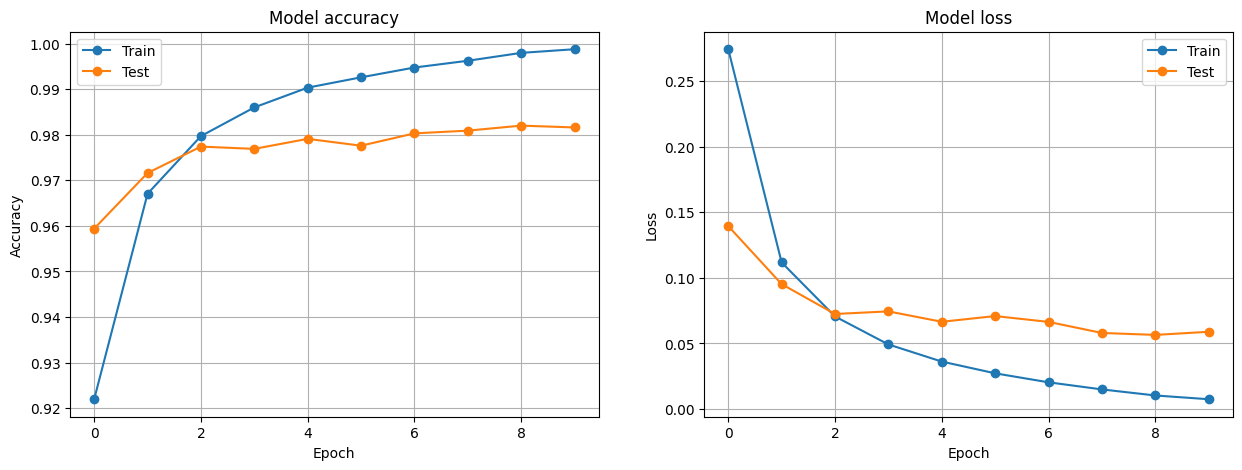

In [ ]:
plot(history)

## Conclusion sur les résultats du modèle

D'après les graphes de l'accuracy et de la loss (perte) :

*   **Accuracy (Précision)** : Le modèle montre une très bonne performance. La précision d'entraînement augmente constamment et la précision de validation se stabilise autour de 98%. On observe un très léger début de surapprentissage après l'époque 8, où la précision de validation diminue un peu.

*   **Loss (Perte)** : La perte d'entraînement diminue continuellement, mais la perte de validation atteint un minimum vers l'époque 8 avant de remonter légèrement. C'est un indicateur plus clair de **surapprentissage** à partir de l'époque 8-9. Le modèle commence à mémoriser les données d'entraînement au détriment de sa capacité à généraliser sur de nouvelles données.

**En résumé** : Le modèle est très performant pour la classification MNIST (environ 98% de précision). Pour une optimisation future, on pourrait envisager un arrêt précoce de l'entraînement (à l'époque 8, par exemple) ou l'ajout de techniques de régularisation pour contrer le surapprentissage.

# Evolution du réseau : augmentation du nombre de couches cachées

On put essayer de construire un réseau avec plus de couches. Par exemple ;



*   couche d'entrée avec les 784 pixels
*   couche cachée 1 : 784 neurones, fonction d'activation `relu`
*   couche cachée 2 : 300 neurones, fonction d'activation `relu`
*   couche cachée 3 : 100 neurones, fonction d'activation `relu`
*   couche de sortie : 10 neurones, fonction d'activation `softmax`









In [ ]:
nb_classes = len(y_train[0])

np.random.seed(43)
model12 = Sequential()
model12.add(Dense(784,input_dim=nb_pixels,kernel_initializer='normal', activation='relu'))
model12.add(Dense(300,kernel_initializer='normal', activation='relu'))
model12.add(Dense(100,kernel_initializer='normal', activation='relu'))
model12.add(Dense(nb_classes,kernel_initializer='normal', activation='softmax'))
model12.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model12.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 882,050 (3.36 MB)

 Trainable params: 882,050 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = model12.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,batch_size=200,verbose=1)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9204 - loss: 0.2819 - val_accuracy: 0.9620 - val_loss: 0.1189
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9719 - loss: 0.0921 - val_accuracy: 0.9726 - val_loss: 0.0864
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9815 - loss: 0.0597 - val_accuracy: 0.9788 - val_loss: 0.0716
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9871 - loss: 0.0398 - val_accuracy: 0.9794 - val_loss: 0.0671
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9900 - loss: 0.0306 - val_accuracy: 0.9789 - val_loss: 0.0680
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9933 - loss: 0.0209 - val_accuracy: 0.9800 - val_loss: 0.0735
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9951 - loss: 0.0158 - val_accuracy: 0.9781 - val_loss: 0.0843
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9947 - loss: 0.0155 - val_a

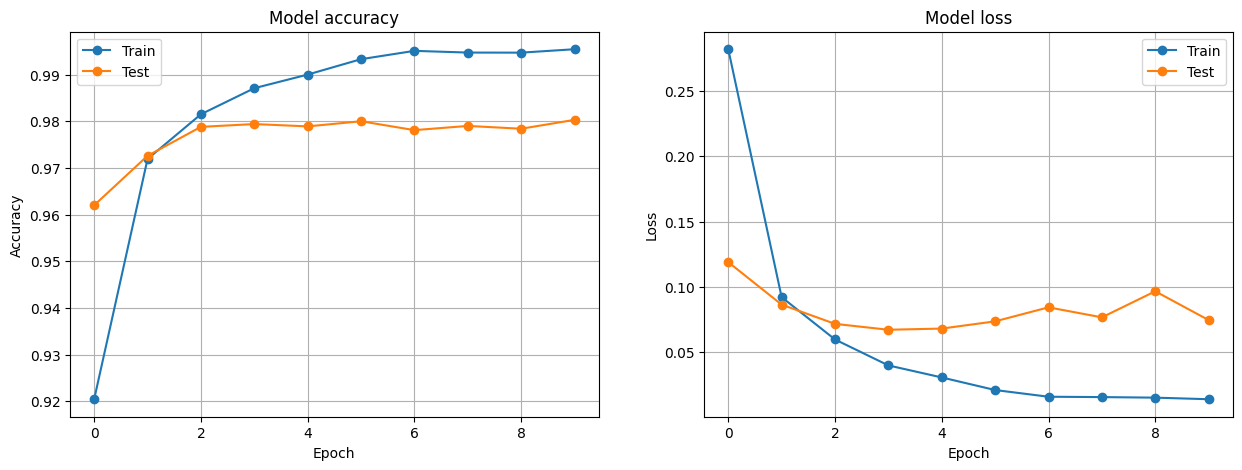

In [ ]:
plot(history2)

## Conclusion sur les résultats du second modèle

Après l'entraînement du modèle avec plus de couches cachées et l'analyse des courbes d'accuracy et de loss (perte), nous pouvons faire les observations suivantes :

*   **Accuracy (Précision)** : Le modèle montre une très bonne performance, similaire au premier modèle. La précision d'entraînement augmente rapidement et la précision de validation se stabilise autour de 98%. On observe également un léger signe de surapprentissage, où la précision de validation peut fluctuer ou légèrement diminuer après un certain nombre d'époques (autour de l'époque 8-9).

*   **Loss (Perte)** : La perte d'entraînement diminue continuellement, tandis que la perte de validation atteint un minimum avant de remonter légèrement. Cela confirme le **surapprentissage** à partir des dernières époques, où le modèle commence à trop bien apprendre les données d'entraînement, ce qui nuit à sa capacité de généralisation sur des données inconnues.

**Comparaison avec le premier modèle** :

Les performances globales (accuracy de validation) des deux modèles sont très similaires, toutes deux atteignant environ 98%. L'ajout de couches cachées n'a pas conduit à une amélioration significative de la précision sur le jeu de test dans ce cas. Les deux modèles montrent des signes de surapprentissage après environ 7-8 époques d'entraînement.

**En résumé** : Bien que l'architecture plus complexe du second modèle n'ait pas apporté de gain substantiel de performance pour cette tâche simple, elle a maintenu un niveau de précision élevé. Pour les deux modèles, une stratégie d'arrêt précoce (early stopping) ou l'application de techniques de régularisation (comme le dropout) pourrait être bénéfique pour mieux gérer le surapprentissage et optimiser le temps d'entraînement.